# Live CAMB 2.0.4 + CosmoRec vs jaxcapse

Compare all five published spectra against a live call to the exact CAMB worker
used for generation. The editable cosmology is checked against the trained
parameter box and `w0 + wa < -0.5` before any model extrapolation. Tables show
pointwise fractional and full-sky, noise-free cosmic-variance residuals; plots
compare each spectrum and its signed cosmic-variance residual.

Run this notebook in the jaxcapse Poetry environment with the neighboring
`tools/CAMB-cosmorec` and `emulator-zoo/Capse.jl/camb_mnuw0wacdm` checkouts.
Set `CAMB_COSMOREC_ROOT` or `CAMB_WORKER_ROOT` if needed.
The comparison figure is stored as inline SVG output.

Plot curves are sampled every fifth multipole to keep the inline SVG compact; all residual tables use every multipole.


In [1]:
import numpy as np

# EDIT THIS CELL to inspect another point in the trained domain.
parameter_names = ("ln10As", "ns", "tau", "H0", "omega_b", "omega_c", "Mnu", "w0", "wa")
lower_bounds = np.array([2.5, 0.85, 0.02, 50.0, 0.02, 0.08, 0.0, -3.0, -3.0])
upper_bounds = np.array([3.5, 1.05, 0.15, 90.0, 0.025, 0.16, 0.5, 0.5, 2.0])
params = np.array([3.044, 0.965, 0.054, 67.4, 0.02237, 0.12, 0.06, -1.0, 0.0], dtype=np.float64)

if params.shape != (9,) or not np.all((lower_bounds <= params) & (params <= upper_bounds)):
    raise ValueError("Cosmology is outside the nine-parameter emulator training bounds")
if params[7] + params[8] >= -0.5:
    raise ValueError("The training domain requires w0 + wa < -0.5")
if params[6] == 0:
    print("Warning: exact Mnu=0 was not represented in the released training sample.")
print("Parameters in training order:", dict(zip(parameter_names, params)))

Parameters in training order: {'ln10As': np.float64(3.044), 'ns': np.float64(0.965), 'tau': np.float64(0.054), 'H0': np.float64(67.4), 'omega_b': np.float64(0.02237), 'omega_c': np.float64(0.12), 'Mnu': np.float64(0.06), 'w0': np.float64(-1.0), 'wa': np.float64(0.0)}


In [2]:
from pathlib import Path
import json
import os
import sys

repo_root = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "jaxcapse" / "__init__.py").is_file()), None)
if repo_root is not None:
    sys.path.insert(0, str(repo_root))

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jaxcapse

jaxcapse_root = Path(jaxcapse.__file__).resolve().parents[1]
workspace = jaxcapse_root.parent
camb_root = Path(os.environ.get("CAMB_COSMOREC_ROOT", workspace / "tools" / "CAMB-cosmorec")).resolve()
worker_root = Path(os.environ.get("CAMB_WORKER_ROOT", workspace / "emulator-zoo" / "Capse.jl" / "camb_mnuw0wacdm")).resolve()
assert (camb_root / "camb" / "camblib.so").is_file(), camb_root
assert (worker_root / "camb_worker.py").is_file(), worker_root
sys.path.insert(0, str(camb_root))
sys.path.insert(0, str(worker_root))
import camb_worker

configuration = camb_worker.backend_configuration()
assert configuration["camb_version"] == "2.0.4"
assert configuration["recombination_model"] == "CosmoRec"
print(f"CAMB {configuration['camb_version']} + {configuration['recombination_model']}")


jaxcapse: Loading emulators into memory...


  camb_mnuw0wacdm: Loaded 5/5 emulators
CAMB 2.0.4 + CosmoRec


In [3]:
spectra = ("TT", "TE", "EE", "BB", "PP")
emulators = jaxcapse.trained_emulators["camb_mnuw0wacdm"]
ell = np.asarray(emulators["TT"].get_ell_grid())
assert np.array_equal(ell, np.arange(2, 9501))
D_jaxcapse = {name: np.asarray(emulators[name].get_Cl(jnp.asarray(params))) for name in spectra}
assert all(values.shape == ell.shape and np.isfinite(values).all() for values in D_jaxcapse.values())

In [4]:
camb_params = dict(zip(parameter_names, params.tolist()))
camb_output = camb_worker.compute_spectra(camb_params, int(ell[-1]))
D_camb = {name: np.asarray(camb_output[f"{name}_dense"]) for name in spectra}
assert all(values.shape == ell.shape and np.isfinite(values).all() for values in D_camb.values())

ell_ranges = (("2-30", 2, 30), ("30-500", 30, 500), ("500-2000", 500, 2000),
              ("2000-3000", 2000, 3000), ("3000-5000", 3000, 5000), ("5000-9500", 5000, 9500))

print("\njaxcapse vs live CAMB (Dℓ ratios; full sky, no noise, Δℓ=1)")
print("spec range        max frac      median frac      max |ΔD|/σCV   median |ΔD|/σCV")
for name in spectra:
    reference = D_camb[name]
    if name == "TE":
        sigma = np.sqrt((D_camb["TT"] * D_camb["EE"] + reference**2) / (2 * ell + 1))
        fractional = None
    else:
        sigma = np.sqrt(2 / (2 * ell + 1)) * np.abs(reference)
        fractional = np.abs(D_jaxcapse[name] - reference) / np.abs(reference)
    cosmic_variance = np.abs(D_jaxcapse[name] - reference) / sigma
    for label, lo, hi in ell_ranges:
        selected = (ell >= lo) & (ell <= hi)
        frac = "       n/a            n/a" if fractional is None else (
            f"{np.max(fractional[selected]):12.3e} {np.median(fractional[selected]):15.3e}"
        )
        print(f"{name:4s} {label:10s} {frac} {np.max(cosmic_variance[selected]):15.3e} {np.median(cosmic_variance[selected]):18.3e}")

ell_200_index = np.flatnonzero(ell == 200)
assert ell_200_index.size == 1
i200 = int(ell_200_index[0])
print(f"\nTT at ℓ=200: CAMB {D_camb['TT'][i200]:.8g}; jaxcapse {D_jaxcapse['TT'][i200]:.8g} μK²")


 || You are entering CosmoRec v3.0 beta (batch mode). Several initializations will be executed now.

 load_rates::Loading effective Rate data (HI) 
 resolved level # 0 :: 2 0 HI_index= 1
 resolved level # 1 :: 2 1 HI_index= 2
 resolved level # 2 :: 3 0 HI_index= 3
 resolved level # 3 :: 3 1 HI_index= 4
 resolved level # 4 :: 3 2 HI_index= 5
 load_rates::finished. # of resolved states: 5 Tg-points: 500


 load_rates::Loading effective Rate data (HeI) 
 resolved level # 0 :: 2 0 s= 0 j= 0 HeI_index= 1
 resolved level # 1 :: 2 1 s= 0 j= 1 HeI_index= 2
 resolved level # 2 :: 2 0 s= 1 j= 1 HeI_index= 3
 resolved level # 3 :: 2 1 s= 1 j= 1 HeI_index= 5
 load_rates::finished. # of resolved states: 4 Tg-points: 500

 Load_fcorr:: Loading correction factor for DPesc due to HI :
 /home/marcobonici/Desktop/work/CosmologicalEmulators/cmbcheb_test/tools/CosmoRec/./Development/Recombination/Data.fcorr/f.corr.dat
 Load_fcorr:: Number of redshift points: 40


 || The first run was successful. Will no

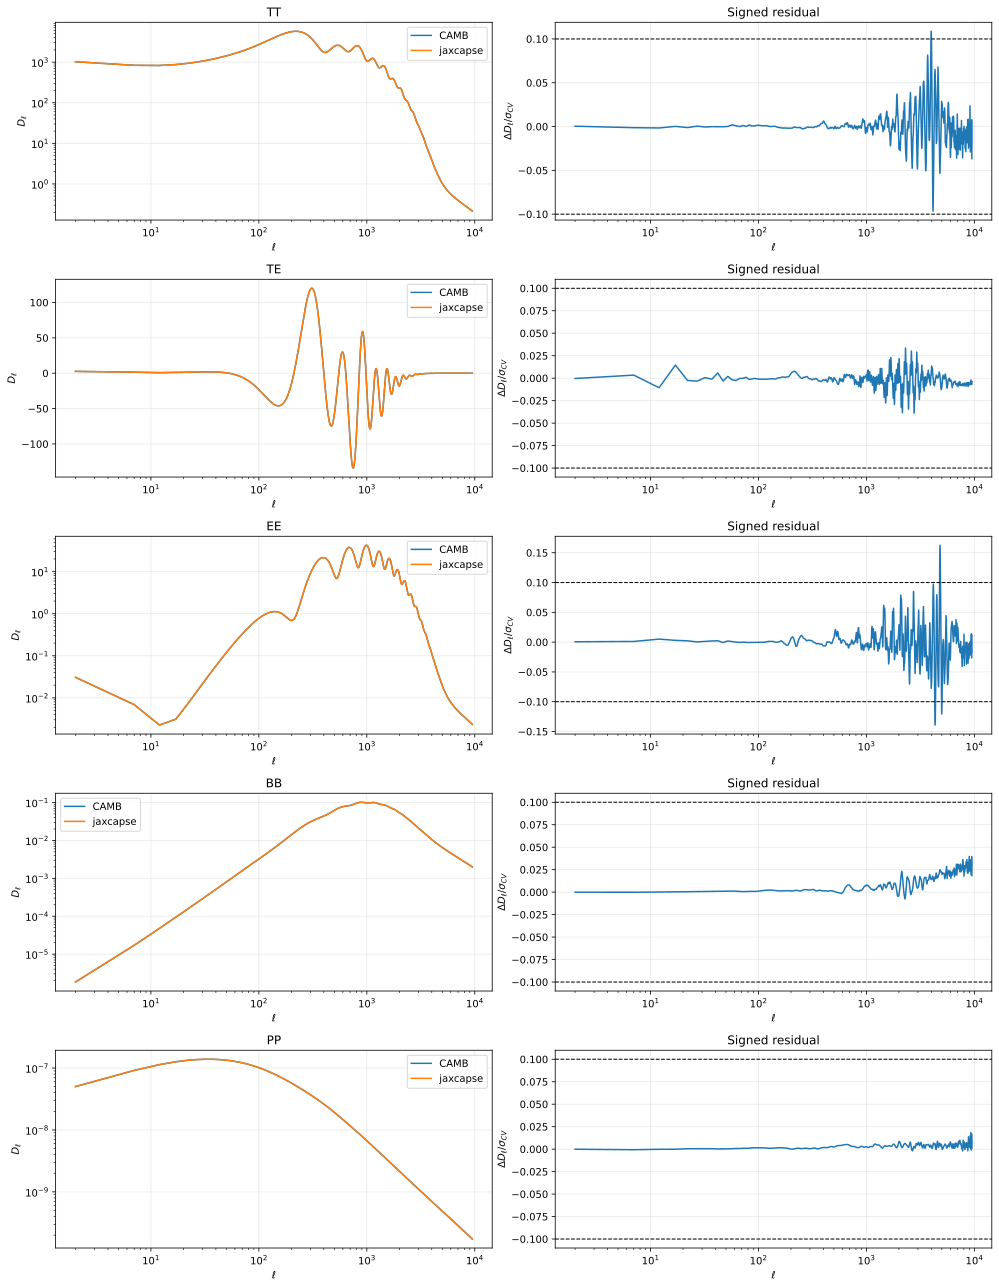

In [5]:
import io
from IPython.display import SVG, display
import matplotlib.pyplot as plt

plot_indices = np.unique(np.r_[np.arange(0, len(ell), 5), len(ell) - 1])
ell_plot = ell[plot_indices]
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
for row, name in enumerate(spectra):
    spectrum_ax, residual_ax = axes[row]
    if name == "TE":
        spectrum_ax.semilogx(ell_plot, D_camb[name][plot_indices], label="CAMB")
        spectrum_ax.semilogx(ell_plot, D_jaxcapse[name][plot_indices], label="jaxcapse")
    else:
        spectrum_ax.loglog(ell_plot, D_camb[name][plot_indices], label="CAMB")
        spectrum_ax.loglog(ell_plot, D_jaxcapse[name][plot_indices], label="jaxcapse")
    spectrum_ax.set(title=name, ylabel=r"$D_\ell$", xlabel=r"$\ell$")
    spectrum_ax.grid(alpha=0.3)
    spectrum_ax.legend()

    if name == "TE":
        sigma = np.sqrt((D_camb["TT"] * D_camb["EE"] + D_camb["TE"]**2) / (2 * ell + 1))
    else:
        sigma = np.sqrt(2 / (2 * ell + 1)) * np.abs(D_camb[name])
    residual_ax.semilogx(ell_plot, (D_jaxcapse[name] - D_camb[name])[plot_indices] / sigma[plot_indices])
    residual_ax.axhline(0.1, color="black", linestyle="--", linewidth=1)
    residual_ax.axhline(-0.1, color="black", linestyle="--", linewidth=1)
    residual_ax.set(title="Signed residual", ylabel=r"$\Delta D_\ell/\sigma_{CV}$", xlabel=r"$\ell$")
    residual_ax.grid(alpha=0.3)

fig.tight_layout()
svg = io.StringIO()
fig.savefig(svg, format="svg", bbox_inches="tight")
display(SVG(svg.getvalue()))
plt.close(fig)